In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

# Define path to the pre-processed SMARD dataset
file_path = (
    "/content/drive/MyDrive/Colab Notebooks/SMARD_Cleaned_20260806_20260816.csv"
)

# Verify file existence
if os.path.exists(file_path):
  print("Dataset found successfully! Proceeding with data loading...")
else:
  print(
      "File not found! Please verify the folder structure in your Google Drive."
  )

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset found successfully! Proceeding with data loading...


 15-MINUTE INTRADAY CONTINUOUS TRADING & OPTIMIZATION BENCHMARK
Simulation Period:                     14 Days (1,344 Quarter-Hours)
Committed Day-Ahead Revenue:           €560,696.42
Unhedged (reBAP Imbalance Penalized):  €406,332.24
Standard ID3 Index Hedging:            €518,557.42
Algorithmic Intraday Trading (Active): €533,240.23
---------------------------------------------------------------------------
PnL Value Uplift vs Unhedged Imbalance: +€126,907.99 (+31.2%)
PnL Value Uplift vs Naive ID3 Hedging:  +€14,682.81 (+2.8%)


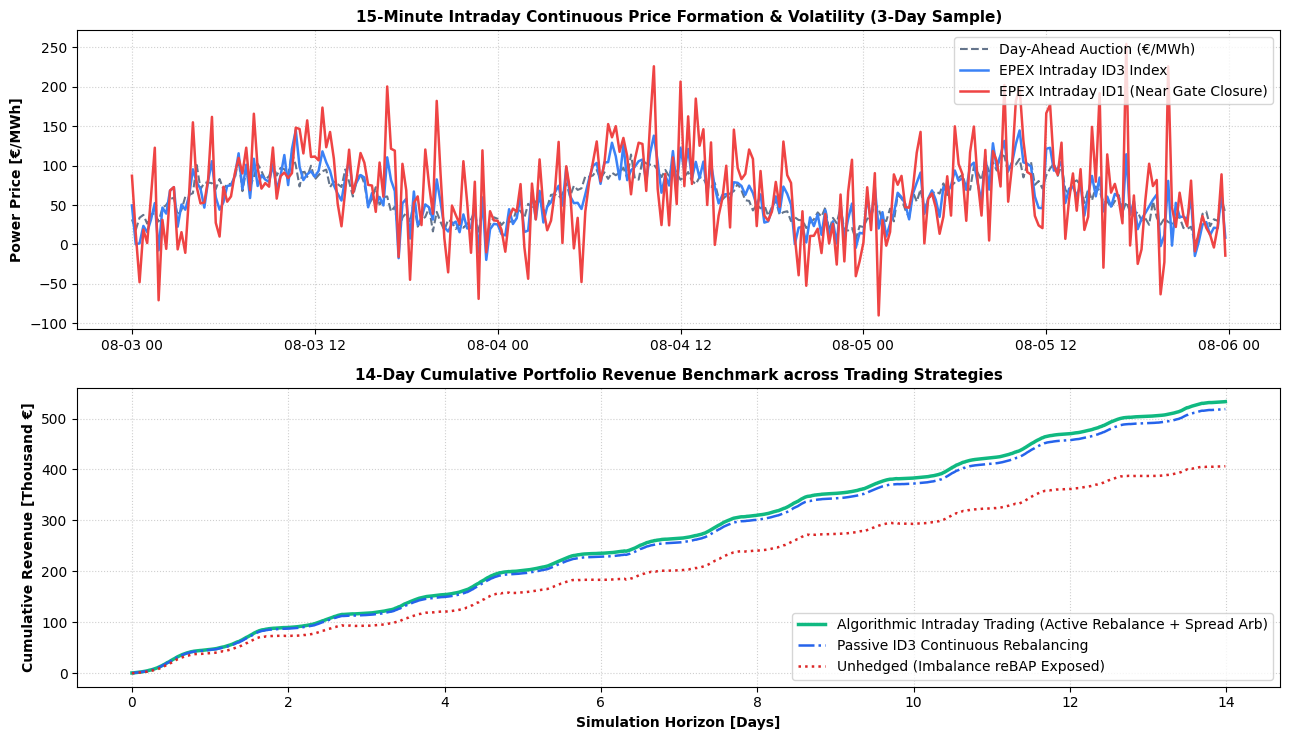

Data exported as 'intraday_continuous_trading_simulation_2026.csv'


In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ==========================================================
# 1. 15-MINUTE INTRADAY CONTINUOUS TRADING SPECIFICATIONS
# ==========================================================
np.random.seed(42)
N_DAYS = 14  # 14-day high-frequency simulation (1,344 quarter-hour blocks)
N_PERIODS = N_DAYS * 24 * 4

timestamps = pd.date_range(
    start="2026-08-01 00:00:00", periods=N_PERIODS, freq="15min"
)
hour_of_day = timestamps.hour.to_numpy() + timestamps.minute.to_numpy() / 60.0

# Day-Ahead Auction Price (€/MWh)
da_price_hourly = (
    60.0
    + 35.0 * np.sin((hour_of_day - 4) * np.pi / 12)
    + np.random.normal(0, 10, N_PERIODS)
)
da_price_15m = np.round(np.clip(da_price_hourly, -20.0, 220.0), 2)

# Day-Ahead Committed Generation (MWh per 15-min block)
solar_da_mw = 20.0 * np.maximum(0, np.sin((hour_of_day - 6) * np.pi / 14))
wind_da_mw = (
    18.0
    + 8.0 * np.sin(np.linspace(0, 8 * np.pi, N_PERIODS))
    + np.random.normal(0, 2, N_PERIODS)
)
da_total_gen_mw = np.clip(solar_da_mw + wind_da_mw, 0, 50.0)
da_committed_mwh_15m = np.round(da_total_gen_mw * 0.25, 2)  # Committed DA Volume

# Real-Time Physical Generation (Intraday Weather Forecast Deviations)
solar_error_mw = np.where(
    solar_da_mw > 0, np.random.normal(-2.5, 4.0, N_PERIODS), 0
)
wind_error_mw = np.random.normal(1.5, 5.0, N_PERIODS)
actual_gen_mw = np.clip(da_total_gen_mw + solar_error_mw + wind_error_mw, 0, 50.0)
actual_gen_mwh_15m = np.round(actual_gen_mw * 0.25, 2)

# Volumetric Delta (Shortage < 0, Surplus > 0)
forecast_delta_mwh = actual_gen_mwh_15m - da_committed_mwh_15m

# ==========================================================
# 2. EPEX INTRADAY PRICE INDICES (ID3, ID1) & REBAP PENALTY
# ==========================================================
ramp_stress = np.abs(np.diff(actual_gen_mw, prepend=actual_gen_mw[0])) * 2.5
id3_price = (
    da_price_15m
    - (forecast_delta_mwh * 12.0)
    + np.random.normal(0, 6, N_PERIODS)
)
id1_price = (
    id3_price
    - (forecast_delta_mwh * 18.0)
    + np.random.normal(0, 12, N_PERIODS)
    + ramp_stress * np.random.choice([-1, 1], N_PERIODS)
)

id3_price = np.round(np.clip(id3_price, -60.0, 320.0), 2)
id1_price = np.round(np.clip(id1_price, -90.0, 380.0), 2)
id_spread_15m = id1_price - id3_price

# reBAP (Imbalance Settlement Penalty)
rebap_price = np.where(
    forecast_delta_mwh < 0,
    np.maximum(id1_price * 1.35, id1_price + 35.0),
    np.minimum(id1_price * 0.65, id1_price - 25.0),
)
rebap_price = np.round(rebap_price, 2)

# ==========================================================
# 3. TRADING STRATEGY EXECUTION & PNL BENCHMARKING
# ==========================================================
rev_da_baseline = da_committed_mwh_15m * da_price_15m

# Strategy 1: Passive / Unhedged (Exposed to reBAP imbalance penalty)
rev_unhedged = rev_da_baseline + (forecast_delta_mwh * rebap_price)

# Strategy 2: Standard ID3 Hedging (100% closed at ID3 index)
rev_id3_hedged = rev_da_baseline + (forecast_delta_mwh * id3_price)

# Strategy 3: Algorithmic Dynamic Intraday Trading (Active Rebalance + 15m Spread Arb)
flex_mw = 5.0  # 5 MW Flexible battery asset
arb_volume_mwh = 0.25 * flex_mw
arb_profit = np.where(
    np.abs(id_spread_15m) > 20.0,
    np.abs(id_spread_15m) * arb_volume_mwh * 0.85,
    0.0,
)
algo_hedge_rev = (forecast_delta_mwh * 0.65 * id3_price) + (
    forecast_delta_mwh * 0.35 * id1_price
)
rev_algo_intraday = rev_da_baseline + algo_hedge_rev + arb_profit

# Performance Metrics
total_da_rev = rev_da_baseline.sum()
total_unhedged_rev = rev_unhedged.sum()
total_id3_rev = rev_id3_hedged.sum()
total_algo_rev = rev_algo_intraday.sum()

pnl_uplift_vs_unhedged = total_algo_rev - total_unhedged_rev
pnl_uplift_vs_id3 = total_algo_rev - total_id3_rev

print('=' * 75)
print(' 15-MINUTE INTRADAY CONTINUOUS TRADING & OPTIMIZATION BENCHMARK')
print('=' * 75)
print('Simulation Period:                     14 Days (1,344 Quarter-Hours)')
print(f'Committed Day-Ahead Revenue:           €{total_da_rev:,.2f}')
print(f'Unhedged (reBAP Imbalance Penalized):  €{total_unhedged_rev:,.2f}')
print(f'Standard ID3 Index Hedging:            €{total_id3_rev:,.2f}')
print(f'Algorithmic Intraday Trading (Active): €{total_algo_rev:,.2f}')
print('-' * 75)
print(
    'PnL Value Uplift vs Unhedged Imbalance:'
    f' +€{pnl_uplift_vs_unhedged:,.2f} (+'
    f'{(pnl_uplift_vs_unhedged/total_unhedged_rev)*100:.1f}%)'
)
print(
    'PnL Value Uplift vs Naive ID3 Hedging: '
    f' +€{pnl_uplift_vs_id3:,.2f} (+{(pnl_uplift_vs_id3/total_id3_rev)*100:.1f}%)'
)
print('=' * 75)

# ==========================================================
# 4. VISUALIZATIONS & EXPORT
# ==========================================================
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 7.5))

# Plot 1: 15-min Price Dynamics (Sample 3 Days)
sample_slice = pd.DataFrame({
    'timestamp': timestamps,
    'da_price_eur': da_price_15m,
    'id3_price_eur': id3_price,
    'id1_price_eur': id1_price,
}).iloc[96 * 2 : 96 * 5]

ax1.plot(
    sample_slice['timestamp'],
    sample_slice['da_price_eur'],
    label='Day-Ahead Auction (€/MWh)',
    color='#64748B',
    lw=1.5,
    linestyle='--',
)
ax1.plot(
    sample_slice['timestamp'],
    sample_slice['id3_price_eur'],
    label='EPEX Intraday ID3 Index',
    color='#3B82F6',
    lw=1.8,
)
ax1.plot(
    sample_slice['timestamp'],
    sample_slice['id1_price_eur'],
    label='EPEX Intraday ID1 (Near Gate Closure)',
    color='#EF4444',
    lw=1.8,
)
ax1.set_title(
    '15-Minute Intraday Continuous Price Formation & Volatility (3-Day'
    ' Sample)',
    fontweight='bold',
    fontsize=11,
)
ax1.set_ylabel('Power Price [€/MWh]', fontweight='bold')
ax1.grid(True, linestyle=':', alpha=0.6)
ax1.legend(loc='upper right')

# Plot 2: Cumulative PnL Trajectories
days_x = np.arange(N_PERIODS) / (24 * 4)
ax2.plot(
    days_x,
    np.cumsum(rev_algo_intraday) / 1000.0,
    label='Algorithmic Intraday Trading (Active Rebalance + Spread Arb)',
    color='#10B981',
    lw=2.5,
)
ax2.plot(
    days_x,
    np.cumsum(rev_id3_hedged) / 1000.0,
    label='Passive ID3 Continuous Rebalancing',
    color='#2563EB',
    lw=1.8,
    linestyle='-.',
)
ax2.plot(
    days_x,
    np.cumsum(rev_unhedged) / 1000.0,
    label='Unhedged (Imbalance reBAP Exposed)',
    color='#DC2626',
    lw=1.8,
    linestyle=':',
)
ax2.set_title(
    '14-Day Cumulative Portfolio Revenue Benchmark across Trading Strategies',
    fontweight='bold',
    fontsize=11,
)
ax2.set_xlabel('Simulation Horizon [Days]', fontweight='bold')
ax2.set_ylabel('Cumulative Revenue [Thousand €]', fontweight='bold')
ax2.grid(True, linestyle=':', alpha=0.6)
ax2.legend(loc='lower right')

plt.tight_layout()
plt.savefig('intraday_continuous_15m_trading_optimization.png', dpi=300)
plt.show()

# Export Simulation Dataset
df_trade = pd.DataFrame({
    'timestamp': timestamps,
    'da_price_eur': da_price_15m,
    'id3_price_eur': id3_price,
    'id1_price_eur': id1_price,
    'rebap_penalty_eur': rebap_price,
    'da_volume_mwh': da_committed_mwh_15m,
    'actual_volume_mwh': actual_gen_mwh_15m,
    'forecast_delta_mwh': forecast_delta_mwh,
    'rev_unhedged_eur': rev_unhedged,
    'rev_id3_hedged_eur': rev_id3_hedged,
    'rev_algo_intraday_eur': rev_algo_intraday,
})
df_trade.to_csv(
    'intraday_continuous_trading_simulation_2026.csv', index=False
)
print("Data exported as 'intraday_continuous_trading_simulation_2026.csv'")